# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [1]:
from google.colab import drive
!rm -rf /content/sample_data/TrafficCollisionAnalysis
drive.mount('/content/sample_data/TrafficCollisionAnalysis')

Mounted at /content/sample_data/TrafficCollisionAnalysis


Install Required Libraries

In [ ]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [2]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [3]:
import os
import pandas as pd

# Define the path to the directory containing CSV files
directory_path = '/content/sample_data/TrafficCollisionAnalysis/MyDrive/TrafficCollisionAnalysis'

# Dictionary to store DataFrames
dataframes = {}

# Check if the directory exists
if not os.path.exists(directory_path):
    print(f"Error: Directory not found at '{directory_path}'. Please verify the path.")
else:
    # List all files in the directory
    files = os.listdir(directory_path)

    # Filter for CSV files
    csv_files = [f for f in files if f.endswith('.csv')]

    if not csv_files:
        print(f"No CSV files found in '{directory_path}'.")
    else:
        print(f"Found {len(csv_files)} CSV file(s) in '{directory_path}':")
        for csv_file in csv_files:
            file_path = os.path.join(directory_path, csv_file)
            df_name = os.path.splitext(csv_file)[0] # Use filename without extension as DataFrame name
            try:
                df = pd.read_csv(file_path)
                dataframes[df_name] = df
                print(f"  - Successfully loaded '{csv_file}' as DataFrame '{df_name}'.")
            except Exception as e:
                print(f"  - Error loading '{csv_file}': {e}")

# Display the first 10 records from each DataFrame
if dataframes:
    print("\nDisplaying the first 10 records from each DataFrame:")
    for df_name, df in dataframes.items():
        print(f"\nDataFrame: {df_name}")
        display(df.head(10))
else:
    print("No DataFrames were loaded.")

Found 4 CSV file(s) in '/content/sample_data/TrafficCollisionAnalysis/MyDrive/TrafficCollisionAnalysis':
  - Successfully loaded 'sample_case_ids.csv' as DataFrame 'sample_case_ids'.
  - Successfully loaded 'sample_victims.csv' as DataFrame 'sample_victims'.
  - Successfully loaded 'sample_parties.csv' as DataFrame 'sample_parties'.
  - Successfully loaded 'sample_collisions.csv' as DataFrame 'sample_collisions'.

Displaying the first 10 records from each DataFrame:

DataFrame: sample_case_ids


,case_id,db_year
0,90017156.0,2021
1,4078685.0,2021
2,90588783.0,2021
3,3351919.0,2018
4,632208.0,2018
5,2465363.0,2018
6,6440794.0,2021
7,3659930.0,2020
8,1562201.0,2018
9,90762102.0,2021



DataFrame: sample_victims


,id,case_id,party_number,victim_role,victim_sex,victim_age,victim_degree_of_injury,victim_seating_position,victim_safety_equipment_1,victim_safety_equipment_2,victim_ejected
0,2166324,6.324923e+06,1,driver,male,62.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
1,779470,7.614730e+05,1,passenger,male,25.0,no injury,passenger seat 3,lap/shoulder harness used,NaN,not ejected
2,742636,7.231230e+05,1,driver,NaN,31.0,complaint of pain,driver,lap/shoulder harness used,NaN,not ejected
3,2412638,2.276798e+06,1,driver,female,51.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
4,4121224,9.011095e+07,1,passenger,female,4.0,no injury,passenger seat 4,not required,child restraint in vehicle used,not ejected
5,1944552,1.900011e+18,1,driver,male,41.0,complaint of pain,driver,lap/shoulder harness used,NaN,not ejected
6,406796,3.994555e+06,1,driver,male,50.0,other visible injury,driver,air bag deployed,lap/shoulder harness used,not ejected
7,825038,8.068430e+05,1,passenger,male,18.0,no injury,passenger seat 3,lap/shoulder harness used,NaN,not ejected
8,1232712,1.203010e+18,2,driver,male,53.0,other visible injury,driver,"driver, motorcycle helmet used",NaN,not ejected
9,3339988,8.326481e+06,1,passenger,male,23.0,no injury,passenger seat 6,lap/shoulder harness used,NaN,not ejected



DataFrame: sample_parties


,id,case_id,party_number,party_type,at_fault,party_sex,party_age,party_sobriety,direction_of_travel,party_safety_equipment_1,...,other_associate_factor_1,party_number_killed,party_number_injured,movement_preceding_collision,vehicle_year,vehicle_make,statewide_vehicle_type,chp_vehicle_type_towing,chp_vehicle_type_towed,party_race
0,1292305,4.843348e+06,1,driver,1,male,28.0,had not been drinking,south,lap/shoulder harness used,...,inattention,0,0,making right turn,1974.0,chevrolet,passenger car,NaN,NaN,NaN
1,3252679,5.965300e+06,2,driver,0,male,53.0,had not been drinking,south,air bag not deployed,...,entering/leaving ramp,0,0,proceeding straight,2000.0,toyota,passenger car,"passenger car, station",00,hispanic
2,5367929,7.110929e+06,2,driver,0,female,22.0,had not been drinking,west,air bag not deployed,...,none apparent,0,0,proceeding straight,2008.0,mazda,passenger car,"passenger car, station",NaN,hispanic
3,1482458,4.945119e+06,2,pedestrian,0,female,52.0,had not been drinking,south,NaN,...,none apparent,0,1,proceeding straight,NaN,NaN,pedestrian,pedestrian,00,hispanic
4,16036906,9.250011e+18,2,driver,0,female,34.0,had not been drinking,south,lap/shoulder harness used,...,none apparent,0,0,proceeding straight,1976.0,ford,passenger car,"passenger car, station",00,NaN
5,7406543,8.989070e+06,1,driver,1,NaN,NaN,impairment unknown,east,NaN,...,none apparent,0,0,proceeding straight,NaN,NaN,NaN,unknown hit and run vehicle involvement,NaN,NaN
6,6368016,8.455738e+06,2,parked vehicle,0,NaN,NaN,not applicable,south,NaN,...,none apparent,0,0,NaN,2005.0,toyota,passenger car,NaN,NaN,NaN
7,1941176,1.074963e+06,2,driver,0,male,47.0,impairment unknown,north,air bag not deployed,...,none apparent,0,1,proceeding straight,2002.0,toyota,NaN,NaN,00,white
8,5750441,3.076506e+06,1,driver,1,female,32.0,had not been drinking,north,air bag deployed,...,none apparent,0,1,making left turn,1994.0,dodge,NaN,NaN,00,hispanic
9,10069065,9.136199e+07,2,driver,0,female,46.0,had not been drinking,west,air bag not deployed,...,none apparent,0,0,proceeding straight,2015.0,honda,passenger car,"passenger car, station",NaN,other



DataFrame: sample_collisions


,case_id,jurisdiction,officer_id,reporting_district,chp_shift,population,county_city_location,county_location,special_condition,beat_type,...,pedestrian_injured_count,bicyclist_killed_count,bicyclist_injured_count,motorcyclist_killed_count,motorcyclist_injured_count,latitude,longitude,collision_date,collision_time,process_date
0,8000993.0,1942.0,39335,1676,not chp,>250000,1942,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2016-03-20,16:30:00,2016-03-30
1,4232117.0,3008.0,1284,Z2,not chp,100000 to 250000,3008,orange,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2009-04-13,18:24:00,2009-11-30
2,91389627.0,9285.0,019223,NaN,1400 thru 2159,unincorporated,5800,yuba,0.0,chp county roadline,...,0,0,0,0,0.0,39.12512,-121.57211,2021-01-09,18:15:00,2021-01-18
3,3589817.0,3610.0,50586,3610,not chp,100000 to 250000,3610,san bernardino,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2007-06-16,21:50:00,2008-03-11
4,9111695.0,1900.0,649318,0261,not chp,25000 to 50000,1917,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2020-04-14,17:56:00,2020-08-03
5,90742339.0,9265.0,017989,NaN,0600 thru 1359,unincorporated,3900,san joaquin,0.0,chp state highway,...,0,0,0,0,0.0,38.11410,-121.39723,2018-05-25,06:05:00,2018-06-06
6,5968565.0,1201.0,592,A205,not chp,10000 to 25000,1201,humboldt,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2012-10-09,08:09:00,2014-04-07
7,1703771.0,2803.0,6,NaN,not chp,2500 to 10000,2803,napa,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2004-11-02,11:45:00,2005-06-30
8,1665179.0,1900.0,439638,0331,not chp,25000 to 50000,1939,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2004-09-18,11:20:00,2005-05-10
9,90988506.0,9535.0,022176,NaN,1400 thru 2159,unincorporated,1900,los angeles,0.0,chp county roadarea,...,0,0,0,0,0.0,34.02370,-118.18130,2019-05-03,14:05:00,2019-05-14


### Loading Data from CSV

we will load data from csv file available in google drive

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [4]:
#Display Schema & Sample Data
if dataframes:
    print("\nDisplaying the first 10 records from each DataFrame:")
    for df_name, df in dataframes.items():
        print(f"\nDataFrame: {df_name}")
        display(df.head(10))
else:
    print("No DataFrames were loaded.")


Displaying the first 10 records from each DataFrame:

DataFrame: sample_case_ids


,case_id,db_year
0,90017156.0,2021
1,4078685.0,2021
2,90588783.0,2021
3,3351919.0,2018
4,632208.0,2018
5,2465363.0,2018
6,6440794.0,2021
7,3659930.0,2020
8,1562201.0,2018
9,90762102.0,2021



DataFrame: sample_victims


,id,case_id,party_number,victim_role,victim_sex,victim_age,victim_degree_of_injury,victim_seating_position,victim_safety_equipment_1,victim_safety_equipment_2,victim_ejected
0,2166324,6.324923e+06,1,driver,male,62.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
1,779470,7.614730e+05,1,passenger,male,25.0,no injury,passenger seat 3,lap/shoulder harness used,NaN,not ejected
2,742636,7.231230e+05,1,driver,NaN,31.0,complaint of pain,driver,lap/shoulder harness used,NaN,not ejected
3,2412638,2.276798e+06,1,driver,female,51.0,complaint of pain,driver,air bag not deployed,lap/shoulder harness used,not ejected
4,4121224,9.011095e+07,1,passenger,female,4.0,no injury,passenger seat 4,not required,child restraint in vehicle used,not ejected
5,1944552,1.900011e+18,1,driver,male,41.0,complaint of pain,driver,lap/shoulder harness used,NaN,not ejected
6,406796,3.994555e+06,1,driver,male,50.0,other visible injury,driver,air bag deployed,lap/shoulder harness used,not ejected
7,825038,8.068430e+05,1,passenger,male,18.0,no injury,passenger seat 3,lap/shoulder harness used,NaN,not ejected
8,1232712,1.203010e+18,2,driver,male,53.0,other visible injury,driver,"driver, motorcycle helmet used",NaN,not ejected
9,3339988,8.326481e+06,1,passenger,male,23.0,no injury,passenger seat 6,lap/shoulder harness used,NaN,not ejected



DataFrame: sample_parties


,id,case_id,party_number,party_type,at_fault,party_sex,party_age,party_sobriety,direction_of_travel,party_safety_equipment_1,...,other_associate_factor_1,party_number_killed,party_number_injured,movement_preceding_collision,vehicle_year,vehicle_make,statewide_vehicle_type,chp_vehicle_type_towing,chp_vehicle_type_towed,party_race
0,1292305,4.843348e+06,1,driver,1,male,28.0,had not been drinking,south,lap/shoulder harness used,...,inattention,0,0,making right turn,1974.0,chevrolet,passenger car,NaN,NaN,NaN
1,3252679,5.965300e+06,2,driver,0,male,53.0,had not been drinking,south,air bag not deployed,...,entering/leaving ramp,0,0,proceeding straight,2000.0,toyota,passenger car,"passenger car, station",00,hispanic
2,5367929,7.110929e+06,2,driver,0,female,22.0,had not been drinking,west,air bag not deployed,...,none apparent,0,0,proceeding straight,2008.0,mazda,passenger car,"passenger car, station",NaN,hispanic
3,1482458,4.945119e+06,2,pedestrian,0,female,52.0,had not been drinking,south,NaN,...,none apparent,0,1,proceeding straight,NaN,NaN,pedestrian,pedestrian,00,hispanic
4,16036906,9.250011e+18,2,driver,0,female,34.0,had not been drinking,south,lap/shoulder harness used,...,none apparent,0,0,proceeding straight,1976.0,ford,passenger car,"passenger car, station",00,NaN
5,7406543,8.989070e+06,1,driver,1,NaN,NaN,impairment unknown,east,NaN,...,none apparent,0,0,proceeding straight,NaN,NaN,NaN,unknown hit and run vehicle involvement,NaN,NaN
6,6368016,8.455738e+06,2,parked vehicle,0,NaN,NaN,not applicable,south,NaN,...,none apparent,0,0,NaN,2005.0,toyota,passenger car,NaN,NaN,NaN
7,1941176,1.074963e+06,2,driver,0,male,47.0,impairment unknown,north,air bag not deployed,...,none apparent,0,1,proceeding straight,2002.0,toyota,NaN,NaN,00,white
8,5750441,3.076506e+06,1,driver,1,female,32.0,had not been drinking,north,air bag deployed,...,none apparent,0,1,making left turn,1994.0,dodge,NaN,NaN,00,hispanic
9,10069065,9.136199e+07,2,driver,0,female,46.0,had not been drinking,west,air bag not deployed,...,none apparent,0,0,proceeding straight,2015.0,honda,passenger car,"passenger car, station",NaN,other



DataFrame: sample_collisions


,case_id,jurisdiction,officer_id,reporting_district,chp_shift,population,county_city_location,county_location,special_condition,beat_type,...,pedestrian_injured_count,bicyclist_killed_count,bicyclist_injured_count,motorcyclist_killed_count,motorcyclist_injured_count,latitude,longitude,collision_date,collision_time,process_date
0,8000993.0,1942.0,39335,1676,not chp,>250000,1942,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2016-03-20,16:30:00,2016-03-30
1,4232117.0,3008.0,1284,Z2,not chp,100000 to 250000,3008,orange,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2009-04-13,18:24:00,2009-11-30
2,91389627.0,9285.0,019223,NaN,1400 thru 2159,unincorporated,5800,yuba,0.0,chp county roadline,...,0,0,0,0,0.0,39.12512,-121.57211,2021-01-09,18:15:00,2021-01-18
3,3589817.0,3610.0,50586,3610,not chp,100000 to 250000,3610,san bernardino,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2007-06-16,21:50:00,2008-03-11
4,9111695.0,1900.0,649318,0261,not chp,25000 to 50000,1917,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2020-04-14,17:56:00,2020-08-03
5,90742339.0,9265.0,017989,NaN,0600 thru 1359,unincorporated,3900,san joaquin,0.0,chp state highway,...,0,0,0,0,0.0,38.11410,-121.39723,2018-05-25,06:05:00,2018-06-06
6,5968565.0,1201.0,592,A205,not chp,10000 to 25000,1201,humboldt,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2012-10-09,08:09:00,2014-04-07
7,1703771.0,2803.0,6,NaN,not chp,2500 to 10000,2803,napa,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2004-11-02,11:45:00,2005-06-30
8,1665179.0,1900.0,439638,0331,not chp,25000 to 50000,1939,los angeles,0.0,not chp,...,0,0,0,0,0.0,NaN,NaN,2004-09-18,11:20:00,2005-05-10
9,90988506.0,9535.0,022176,NaN,1400 thru 2159,unincorporated,1900,los angeles,0.0,chp county roadarea,...,0,0,0,0,0.0,34.02370,-118.18130,2019-05-03,14:05:00,2019-05-14


##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [5]:
#Check for Missing Values
for df_name, df in dataframes.items():
    print(f"\nMissing values in DataFrame: {df_name}")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0])


Missing values in DataFrame: sample_case_ids
Series([], dtype: int64)

Missing values in DataFrame: sample_victims
victim_role                       1
victim_sex                    24041
victim_age                    32145
victim_seating_position        1913
victim_safety_equipment_1     55215
victim_safety_equipment_2    310220
victim_ejected                 4272
dtype: int64

Missing values in DataFrame: sample_parties
party_type                        4395
party_sex                       249269
party_age                       290783
party_sobriety                   55663
direction_of_travel              52377
party_safety_equipment_1        314883
party_safety_equipment_2        699581
financial_responsibility        152613
cellphone_in_use                568197
cellphone_use_type              432264
other_associate_factor_1        112496
movement_preceding_collision     33275
vehicle_year                    177599
vehicle_make                    195057
statewide_vehicle_type      

In [6]:
#Drop Sparse Columns
for df_name, df in dataframes.items():
    print(f"\nHandling missing values for DataFrame: {df_name}")

    # Identify numerical and categorical columns with missing values
    numerical_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(include=['object']).columns

    for col in df.columns:
        if df[col].isnull().any():
            if col in ['victim_age', 'party_age', 'vehicle_year']:
                # Replace numerical columns with median
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - Replace '{col}' with median: {median_val}")
            elif col in ['killed_victims', 'injured_victims']:
                # Replace victim counts with 0, assuming missing means none
                df[col] = df[col].fillna(0)
                print(f"  - d '{col}' with 0")
            elif col == 'collision_time':
                #  collision_time (often treated as categorical in this context) with mode
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - d '{col}' with mode: {mode_val}")
            elif col in categorical_cols:
                #  other categorical columns with 'Unknown' or mode
                # For now, let's use mode for simplicity, but 'Unknown' is also a valid strategy
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - d '{col}' with mode: {mode_val}")
            elif col in numerical_cols:
                # For any remaining numerical columns, use median imputation
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - d '{col}' with median: {median_val}")

    dataframes[df_name] = df # Update the dataframe in the dictionary


print("\nMissing values after replacement:")
for df_name, df in dataframes.items():
    print(f"\nMissing values in DataFrame: {df_name}")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0])


Handling missing values for DataFrame: sample_case_ids

Handling missing values for DataFrame: sample_victims
  - d 'victim_role' with mode: passenger
  - d 'victim_sex' with mode: female
  - Replace 'victim_age' with median: 27.0
  - d 'victim_seating_position' with mode: driver
  - d 'victim_safety_equipment_1' with mode: air bag not deployed
  - d 'victim_safety_equipment_2' with mode: lap/shoulder harness used
  - d 'victim_ejected' with mode: not ejected

Handling missing values for DataFrame: sample_parties
  - d 'party_type' with mode: driver
  - d 'party_sex' with mode: male
  - Replace 'party_age' with median: 36.0
  - d 'party_sobriety' with mode: had not been drinking
  - d 'direction_of_travel' with mode: south
  - d 'party_safety_equipment_1' with mode: air bag not deployed
  - d 'party_safety_equipment_2' with mode: lap/shoulder harness used
  - d 'financial_responsibility' with mode: proof of insurance obtained
  - d 'cellphone_in_use' with median: 0.0
  - d 'cellphone_

In [7]:
#Handle Missing Values

for df_name, df in dataframes.items():
    print(f"\nHandling missing values for DataFrame: {df_name}")

    # Identify numerical and categorical columns with missing values
    numerical_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(include=['object']).columns

    for col in df.columns:
        if df[col].isnull().any():
            if col in ['victim_age', 'party_age', 'vehicle_year']:
                # Replace numerical columns with median
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - Replace '{col}' with median: {median_val}")
            elif col in ['killed_victims', 'injured_victims']:
                # Replace victim counts with 0, assuming missing means none
                df[col] = df[col].fillna(0)
                print(f"  - d '{col}' with 0")
            elif col == 'collision_time':
                #  collision_time (often treated as categorical in this context) with mode
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - d '{col}' with mode: {mode_val}")
            elif col in categorical_cols:
                #  other categorical columns with 'Unknown' or mode
                # For now, let's use mode for simplicity, but 'Unknown' is also a valid strategy
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - d '{col}' with mode: {mode_val}")
            elif col in numerical_cols:
                # For any remaining numerical columns, use median imputation
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - d '{col}' with median: {median_val}")

    dataframes[df_name] = df # Update the dataframe in the dictionary


print("\nMissing values after replacement:")
for df_name, df in dataframes.items():
    print(f"\nMissing values in DataFrame: {df_name}")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0])


Handling missing values for DataFrame: sample_case_ids

Handling missing values for DataFrame: sample_victims

Handling missing values for DataFrame: sample_parties

Handling missing values for DataFrame: sample_collisions

Missing values after replacement:

Missing values in DataFrame: sample_case_ids
Series([], dtype: int64)

Missing values in DataFrame: sample_victims
Series([], dtype: int64)

Missing values in DataFrame: sample_parties
Series([], dtype: int64)

Missing values in DataFrame: sample_collisions
Series([], dtype: int64)


In [8]:
#Convert Data Types
column_conversions = {
    'case_id': 'Int64', # Nullable integer type
    'party_number': 'Int64' # Nullable integer type
}

# Iterate through each dataframe and apply conversions
for df_name, df in dataframes.items():
    print(f"\nConverting data types for DataFrame: {df_name}")
    for col, dtype in column_conversions.items():
        if col in df.columns:
            try:
                # Convert numerical IDs that might be float due to NaNs to Int64 (nullable integer)
                df[col] = df[col].astype(dtype)
                print(f"  - Converted '{col}' to {dtype}")
            except Exception as e:
                print(f"  - Could not convert '{col}' to {dtype} in {df_name}: {e}")

    # Handle specific date column conversion for sample_collisions
    if df_name == 'sample_collisions' and 'collision_date' in df.columns:
        try:
            df['collision_date'] = pd.to_datetime(df['collision_date'])
            print(f"  - Converted 'collision_date' to datetime type")
        except Exception as e:
            print(f"  - Could not convert 'collision_date' to datetime in {df_name}: {e}")

    dataframes[df_name] = df # Update the dataframe in the dictionary


# Display DataFrame info to verify data types after conversion
print("\n--- DataFrames Info After Type Conversion ---")
for df_name, df in dataframes.items():
    print(f"\nDataFrame: {df_name}")
    df.info()


Converting data types for DataFrame: sample_case_ids


/usr/local/lib/python3.12/dist-packages/pandas/core/arrays/integer.py:55: RuntimeWarning: invalid value encountered in cast
  casted = values.astype(dtype, copy=copy)


  - Could not convert 'case_id' to Int64 in sample_case_ids: cannot safely cast non-equivalent float64 to int64

Converting data types for DataFrame: sample_victims
  - Could not convert 'case_id' to Int64 in sample_victims: cannot safely cast non-equivalent float64 to int64
  - Converted 'party_number' to Int64

Converting data types for DataFrame: sample_parties
  - Could not convert 'case_id' to Int64 in sample_parties: cannot safely cast non-equivalent float64 to int64
  - Converted 'party_number' to Int64

Converting data types for DataFrame: sample_collisions
  - Could not convert 'case_id' to Int64 in sample_collisions: cannot safely cast non-equivalent float64 to int64
  - Converted 'collision_date' to datetime type

--- DataFrames Info After Type Conversion ---

DataFrame: sample_case_ids
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 942433 entries, 0 to 942432
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0 

In [9]:
#Handle Missing Values

for df_name, df in dataframes.items():
    print(f"\nHandling missing values for DataFrame: {df_name}")

    # Identify numerical and categorical columns with missing values
    numerical_cols = df.select_dtypes(include=['number']).columns
    categorical_cols = df.select_dtypes(include=['object']).columns

    for col in df.columns:
        if df[col].isnull().any():
            if col in ['victim_age', 'party_age', 'vehicle_year']:
                # Impute numerical columns with median
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - Imputed '{col}' with median: {median_val}")
            elif col in ['killed_victims', 'injured_victims']:
                # Impute victim counts with 0, assuming missing means none
                df[col] = df[col].fillna(0)
                print(f"  - Imputed '{col}' with 0")
            elif col == 'collision_time':
                # Impute collision_time (often treated as categorical in this context) with mode
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - Imputed '{col}' with mode: {mode_val}")
            elif col in categorical_cols:
                # Impute other categorical columns with 'Unknown' or mode
                # For now, let's use mode for simplicity, but 'Unknown' is also a valid strategy
                mode_val = df[col].mode()[0]
                df[col] = df[col].fillna(mode_val)
                print(f"  - Imputed '{col}' with mode: {mode_val}")
            elif col in numerical_cols:
                # For any remaining numerical columns, use median imputation
                median_val = df[col].median()
                df[col] = df[col].fillna(median_val)
                print(f"  - Imputed '{col}' with median: {median_val}")

    dataframes[df_name] = df # Update the dataframe in the dictionary


print("\nMissing values after imputation:")
for df_name, df in dataframes.items():
    print(f"\nMissing values in DataFrame: {df_name}")
    missing_values = df.isnull().sum()
    print(missing_values[missing_values > 0])


Handling missing values for DataFrame: sample_case_ids

Handling missing values for DataFrame: sample_victims

Handling missing values for DataFrame: sample_parties

Handling missing values for DataFrame: sample_collisions

Missing values after imputation:

Missing values in DataFrame: sample_case_ids
Series([], dtype: int64)

Missing values in DataFrame: sample_victims
Series([], dtype: int64)

Missing values in DataFrame: sample_parties
Series([], dtype: int64)

Missing values in DataFrame: sample_collisions
Series([], dtype: int64)


##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [10]:
#Remove Duplicates

# List of dataframes to process based on user request
dfs_to_process = ['sample_victims', 'sample_parties', 'sample_collisions']

for df_name in dfs_to_process:
    if df_name in dataframes:
        df = dataframes[df_name]
        initial_rows = len(df)
        df_cleaned = df.drop_duplicates()
        dataframes[df_name] = df_cleaned # Update the dataframe in the dictionary
        rows_after_dedup = len(dataframes[df_name])

        print(f"\nDataFrame: {df_name}")
        print(f"  Initial rows: {initial_rows}")
        print(f"  Rows after removing duplicates: {rows_after_dedup}")
        print(f"  Number of duplicates removed: {initial_rows - rows_after_dedup}")
    else:
        print(f"DataFrame '{df_name}' not found in the dictionary.")

print("\nDuplicate removal complete for the specified dataframes.")



DataFrame: sample_victims
  Initial rows: 963933
  Rows after removing duplicates: 963933
  Number of duplicates removed: 0

DataFrame: sample_parties
  Initial rows: 1866917
  Rows after removing duplicates: 1866917
  Number of duplicates removed: 0

DataFrame: sample_collisions
  Initial rows: 935791
  Rows after removing duplicates: 935791
  Number of duplicates removed: 0

Duplicate removal complete for the specified dataframes.


In [12]:
#Detect Outliers using IQR

# List of numerical columns to check for outliers
import numpy as np

# Dataframes to analyze
dfs_to_process = ['sample_victims', 'sample_parties', 'sample_collisions']

print("\n--- Identifying Numerical Columns and Detecting Outliers using IQR ---")

for df_name in dfs_to_process:
    if df_name in dataframes:
        df = dataframes[df_name]
        print(f"\nAnalyzing DataFrame: {df_name}")

        numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
        print(f"  Numerical columns identified: {numerical_cols}")

        if not numerical_cols:
            print(f"  No numerical columns found in {df_name} for outlier detection.")
            continue

        for col in numerical_cols:
            # Skip case_id and id columns if they are purely identifiers and not true numerical features for outlier analysis
            if col in ['id', 'case_id']:
                print(f"  Skipping '{col}' for outlier detection as it's likely an identifier.")
                continue

            # Calculate Q1, Q3, and IQR
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1

            # Define outlier bounds
            lower_bound = Q1 - (1.5 * IQR)
            upper_bound = Q3 + (1.5 * IQR)

            # Identify outliers
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

            print(f"  Column '{col}':")
            print(f"    Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
            print(f"    Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
            print(f"    Number of outliers detected: {len(outliers)}")
            if not outliers.empty:
                print(f"    Min outlier value: {outliers[col].min():.2f}, Max outlier value: {outliers[col].max():.2f}")
    else:
        print(f"DataFrame '{df_name}' not found.")


--- Identifying Numerical Columns and Detecting Outliers using IQR ---

Analyzing DataFrame: sample_victims
  Numerical columns identified: ['id', 'case_id', 'party_number', 'victim_age']
  Skipping 'id' for outlier detection as it's likely an identifier.
  Skipping 'case_id' for outlier detection as it's likely an identifier.
  Column 'party_number':
    Q1: 1.00, Q3: 2.00, IQR: 1.00
    Lower Bound: -0.50, Upper Bound: 3.50
    Number of outliers detected: 12976
    Min outlier value: 4.00, Max outlier value: 88.00
  Column 'victim_age':
    Q1: 18.00, Q3: 44.00, IQR: 26.00
    Lower Bound: -21.00, Upper Bound: 83.00
    Number of outliers detected: 6888
    Min outlier value: 84.00, Max outlier value: 999.00

Analyzing DataFrame: sample_parties
  Numerical columns identified: ['id', 'case_id', 'party_number', 'at_fault', 'party_age', 'cellphone_in_use', 'party_number_killed', 'party_number_injured', 'vehicle_year']
  Skipping 'id' for outlier detection as it's likely an identifier.

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [13]:
#Remove Outliers

# Dictionary to store cleaned dataframes
dataframes_cleaned = dataframes.copy()

# Columns identified for outlier removal due to likely data errors
columns_for_filtering = {
    'sample_victims': 'victim_age',
    'sample_parties': ['party_age', 'vehicle_year'],
    'sample_collisions': 'distance'
}

print("\n--- Filtering Outliers from DataFrames ---")

for df_name, cols_to_filter in columns_for_filtering.items():
    if df_name in dataframes_cleaned:
        df = dataframes_cleaned[df_name]
        initial_rows = len(df)
        print(f"\nProcessing DataFrame: {df_name} (Initial rows: {initial_rows})")

        # Ensure cols_to_filter is always a list for consistent iteration
        if not isinstance(cols_to_filter, list):
            cols_to_filter = [cols_to_filter]

        for col in cols_to_filter:
            if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
                Q1 = df[col].quantile(0.25)
                Q3 = df[col].quantile(0.75)
                IQR = Q3 - Q1
                lower_bound = Q1 - (1.5 * IQR)
                upper_bound = Q3 + (1.5 * IQR)

                # Filter out rows where the column value is outside the IQR bounds
                df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
                print(f"  - Filtered outliers for column '{col}'. Rows remaining: {len(df)}")
            else:
                print(f"  - Skipping '{col}' in {df_name}: not found or not numeric.")

        dataframes_cleaned[df_name] = df # Update the cleaned dataframe in the dictionary
        rows_after_filtering = len(dataframes_cleaned[df_name])
        print(f"  Total rows after filtering in {df_name}: {rows_after_filtering}")
        print(f"  Rows removed from {df_name}: {initial_rows - rows_after_filtering}")
    else:
        print(f"DataFrame '{df_name}' not found in the dictionary.")

print("\nOutlier filtering complete. Cleaned DataFrames are stored in 'dataframes_cleaned'.")

# Display the shape of the cleaned dataframes to confirm
print("\nShape of DataFrames after outlier removal:")
for df_name, df_cleaned in dataframes_cleaned.items():
    print(f"  {df_name}: {df_cleaned.shape[0]} rows, {df_cleaned.shape[1]} columns")


--- Filtering Outliers from DataFrames ---

Processing DataFrame: sample_victims (Initial rows: 963933)
  - Filtered outliers for column 'victim_age'. Rows remaining: 957045
  Total rows after filtering in sample_victims: 957045
  Rows removed from sample_victims: 6888

Processing DataFrame: sample_parties (Initial rows: 1866917)
  - Filtered outliers for column 'party_age'. Rows remaining: 1837311
  - Filtered outliers for column 'vehicle_year'. Rows remaining: 1800202
  Total rows after filtering in sample_parties: 1800202
  Rows removed from sample_parties: 66715

Processing DataFrame: sample_collisions (Initial rows: 935791)
  - Filtered outliers for column 'distance'. Rows remaining: 830814
  Total rows after filtering in sample_collisions: 830814
  Rows removed from sample_collisions: 104977

Outlier filtering complete. Cleaned DataFrames are stored in 'dataframes_cleaned'.

Shape of DataFrames after outlier removal:
  sample_case_ids: 942433 rows, 2 columns
  sample_victims: 95

#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [14]:
# Encode Categorical Variables

# String Indexing for Categorical Columns
import numpy as np

# List of dataframes to process
dfs_to_encode = ['sample_victims', 'sample_parties', 'sample_collisions']

print("--- Encoding Categorical Variables using String Indexing ---")

for df_name in dfs_to_encode:
    if df_name in dataframes_cleaned:
        df = dataframes_cleaned[df_name]
        print(f"\nProcessing DataFrame: {df_name}")

        # Identify categorical columns (object type)
        categorical_cols = df.select_dtypes(include=['object']).columns
        print(f"  Categorical columns identified: {list(categorical_cols)}")

        if categorical_cols.empty:
            print(f"  No categorical columns to encode in {df_name}.")
            continue

        for col in categorical_cols:
            # Apply factorize to get numerical labels and unique categories
            # -1 for NaN values will be handled by pandas.factorize automatically
            df[col + '_encoded'], unique_labels = pd.factorize(df[col])
            print(f"  - Encoded '{col}' into '{col}_encoded' (unique labels: {len(unique_labels)})")
            # Optionally, drop the original categorical column if not needed later
            # df = df.drop(columns=[col])

        dataframes_cleaned[df_name] = df # Update the dataframe in the dictionary
    else:
        print(f"DataFrame '{df_name}' not found in 'dataframes_cleaned'.")

print("\nCategorical encoding complete.")

# Display info for a sample dataframe to verify
print("\n--- Sample DataFrame Info After Encoding (e.g., sample_victims) ---")
if 'sample_victims' in dataframes_cleaned:
    dataframes_cleaned['sample_victims'].info()

--- Encoding Categorical Variables using String Indexing ---

Processing DataFrame: sample_victims
  Categorical columns identified: ['victim_role', 'victim_sex', 'victim_degree_of_injury', 'victim_seating_position', 'victim_safety_equipment_1', 'victim_safety_equipment_2', 'victim_ejected']
  - Encoded 'victim_role' into 'victim_role_encoded' (unique labels: 6)
  - Encoded 'victim_sex' into 'victim_sex_encoded' (unique labels: 6)


/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

  - Encoded 'victim_degree_of_injury' into 'victim_degree_of_injury_encoded' (unique labels: 8)
  - Encoded 'victim_seating_position' into 'victim_seating_position_encoded' (unique labels: 12)
  - Encoded 'victim_safety_equipment_1' into 'victim_safety_equipment_1_encoded' (unique labels: 27)


/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation:

  - Encoded 'victim_safety_equipment_2' into 'victim_safety_equipment_2_encoded' (unique labels: 25)
  - Encoded 'victim_ejected' into 'victim_ejected_encoded' (unique labels: 7)

Processing DataFrame: sample_parties
  Categorical columns identified: ['party_type', 'party_sex', 'party_sobriety', 'direction_of_travel', 'party_safety_equipment_1', 'party_safety_equipment_2', 'financial_responsibility', 'cellphone_use_type', 'other_associate_factor_1', 'movement_preceding_collision', 'vehicle_make', 'statewide_vehicle_type', 'chp_vehicle_type_towing', 'chp_vehicle_type_towed', 'party_race']
  - Encoded 'party_type' into 'party_type_encoded' (unique labels: 6)
  - Encoded 'party_sex' into 'party_sex_encoded' (unique labels: 3)
  - Encoded 'party_sobriety' into 'party_sobriety_encoded' (unique labels: 6)
  - Encoded 'direction_of_travel' into 'direction_of_travel_encoded' (unique labels: 4)
  - Encoded 'party_safety_equipment_1' into 'party_safety_equipment_1_encoded' (unique labels: 23)
  

...

  - Encoded 'lighting' into 'lighting_encoded' (unique labels: 5)
  - Encoded 'control_device' into 'control_device_encoded' (unique labels: 5)


/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])


  - Encoded 'statewide_vehicle_type_at_fault' into 'statewide_vehicle_type_at_fault_encoded' (unique labels: 15)
  - Encoded 'chp_vehicle_type_at_fault' into 'chp_vehicle_type_at_fault_encoded' (unique labels: 86)


/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])
/tmp/ipykernel_5615/2223790157.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col + '_encoded'], unique_labels = pd.factorize(df[col])


  - Encoded 'collision_time' into 'collision_time_encoded' (unique labels: 1440)
  - Encoded 'process_date' into 'process_date_encoded' (unique labels: 5477)

Categorical encoding complete.

--- Sample DataFrame Info After Encoding (e.g., sample_victims) ---
<class 'pandas.core.frame.DataFrame'>
Index: 957045 entries, 0 to 963932
Data columns (total 18 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 957045 non-null  int64  
 1   case_id                            957045 non-null  float64
 2   party_number                       957045 non-null  Int64  
 3   victim_role                        957045 non-null  object 
 4   victim_sex                         957045 non-null  object 
 5   victim_age                         957045 non-null  float64
 6   victim_degree_of_injury            957045 non-null  object 
 7   victim_seating_position            957045 non

In [ ]:
# Reordering & Renaming Columns
#as above

In [ ]:
# Final cleaned data
#as above

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

/tmp/ipykernel_5615/1829350557.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='collision_severity', y='count', data=severity_distribution, palette='viridis')


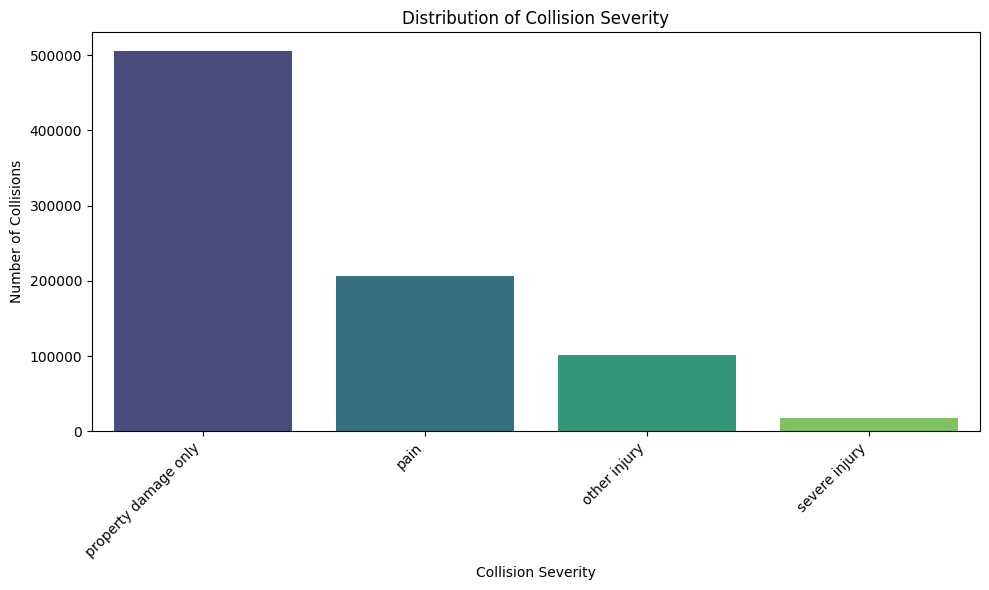

In [15]:
# Univariate Analysis

# Collision Severity Distribution

# Convert to Pandas

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Calculate the distribution of collision_severity
severity_distribution = collisions_df['collision_severity'].value_counts().reset_index()
severity_distribution.columns = ['collision_severity', 'count']

# Convert to Pandas (already in pandas, just ensuring)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.barplot(x='collision_severity', y='count', data=severity_distribution, palette='viridis')
plt.title('Distribution of Collision Severity')
plt.xlabel('Collision Severity')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

/tmp/ipykernel_5615/875651112.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_condition', y='count', data=weather_distribution, palette='plasma')


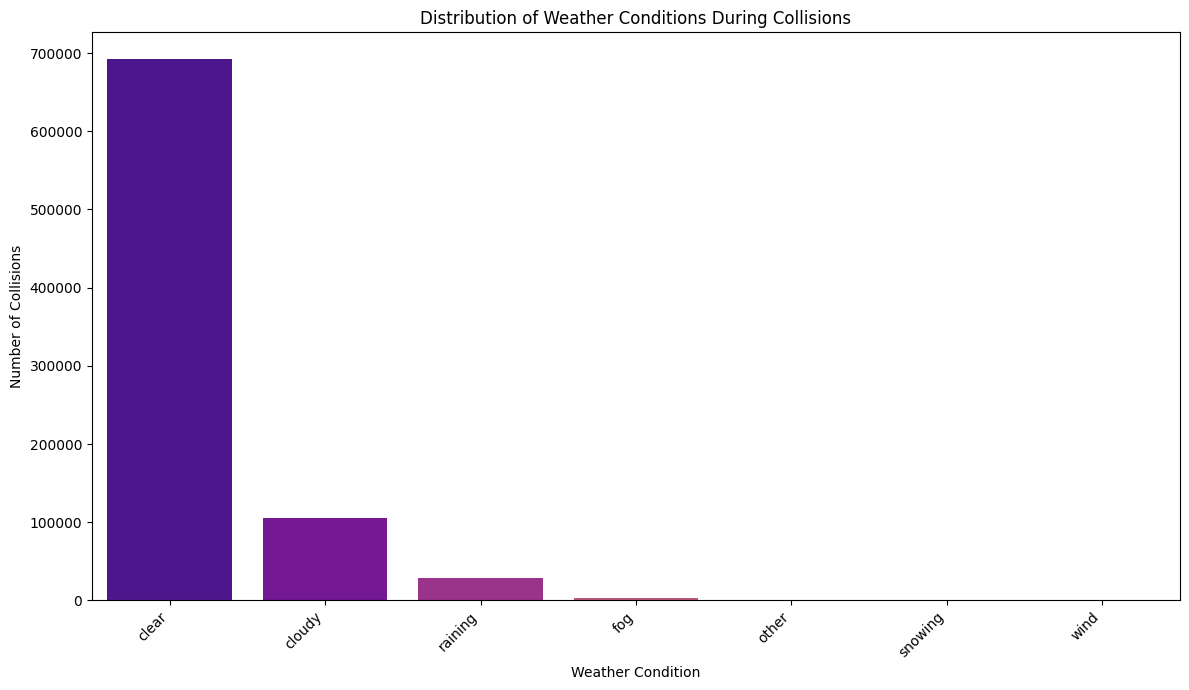

In [16]:
# Weather Conditions During Collisions

# Convert to Pandas

# Plot


import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Calculate the distribution of weather conditions
weather_distribution = collisions_df['weather_1'].value_counts().reset_index()
weather_distribution.columns = ['weather_condition', 'count']

# Plot the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x='weather_condition', y='count', data=weather_distribution, palette='plasma')
plt.title('Distribution of Weather Conditions During Collisions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

/tmp/ipykernel_5615/2887275645.py:15: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(victims_df['victim_age'], bins=20, kde=True, palette='coolwarm')


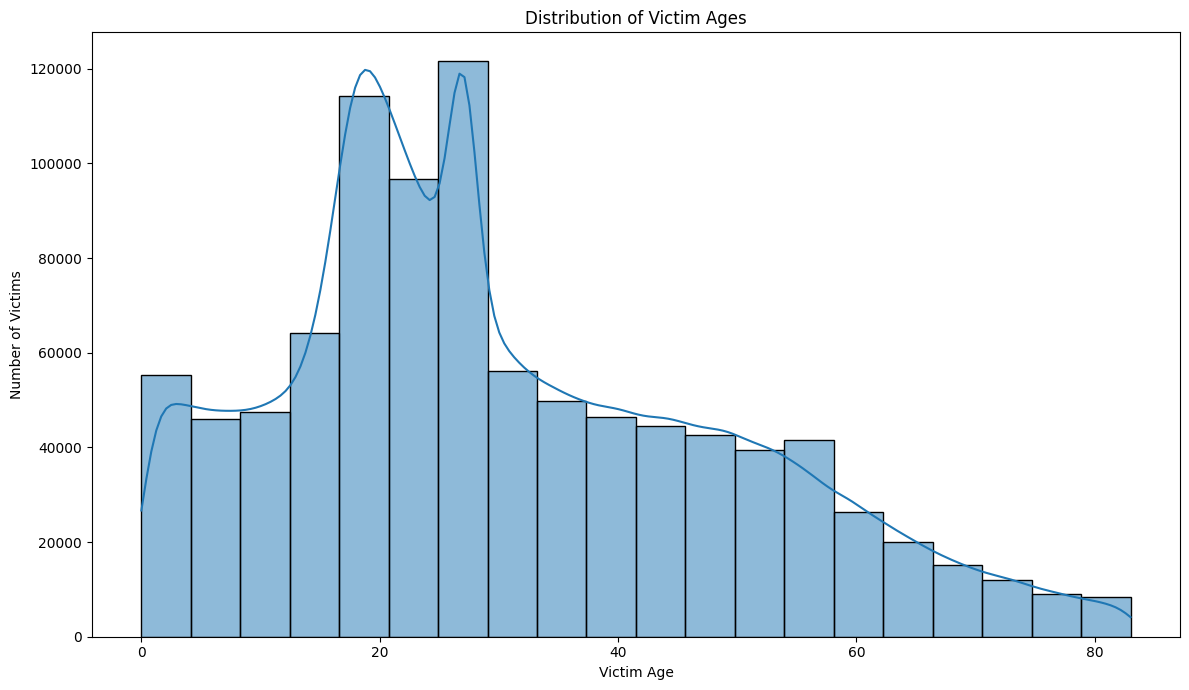

In [17]:
# Distribution of Victim Ages

# Convert to Pandas

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_victims' DataFrame from dataframes_cleaned
victims_df = dataframes_cleaned['sample_victims']

# Plot the distribution of victim ages using a histogram
plt.figure(figsize=(12, 7))
sns.histplot(victims_df['victim_age'], bins=20, kde=True, palette='coolwarm')
plt.title('Distribution of Victim Ages')
plt.xlabel('Victim Age')
plt.ylabel('Number of Victims')
plt.tight_layout()
plt.show()


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

/tmp/ipykernel_5615/4226031672.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collisions_df['total_victims'] = collisions_df['killed_victims'] + collisions_df['injured_victims']
/tmp/ipykernel_5615/4226031672.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='collision_severity', y='total_victims', data=severity_victims, palette='magma')


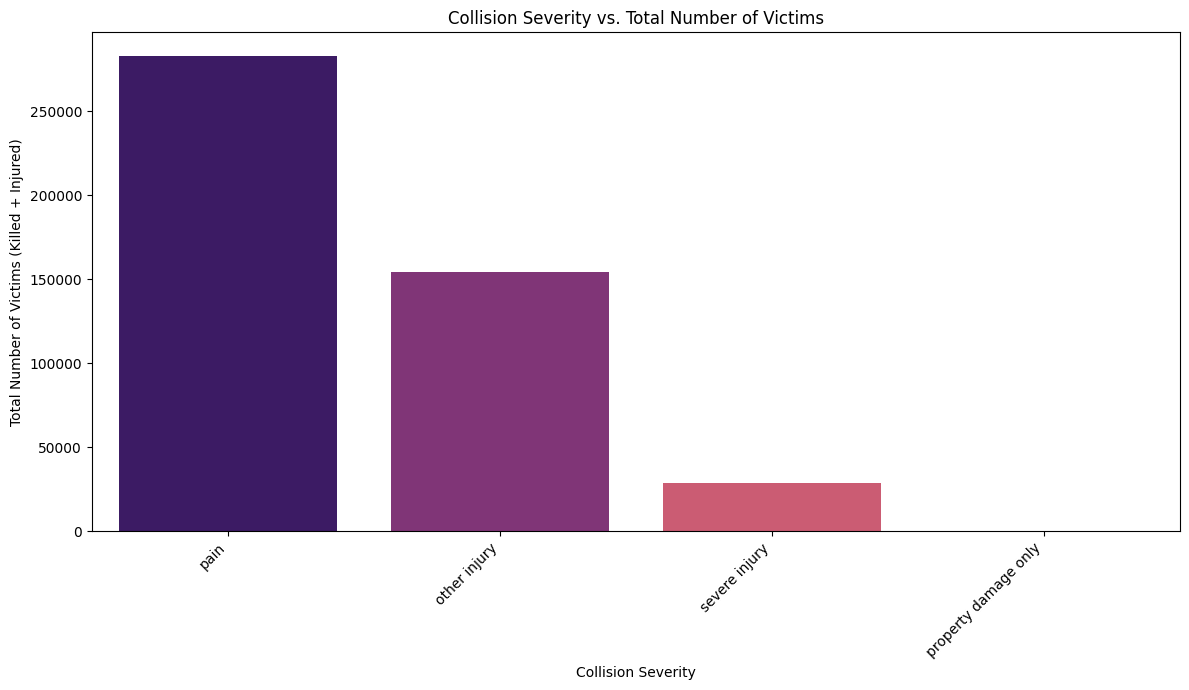

In [18]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Convert to Pandas

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Calculate total victims (killed + injured) for each collision
collisions_df['total_victims'] = collisions_df['killed_victims'] + collisions_df['injured_victims']

# Group by collision_severity and sum the total victims
severity_victims = collisions_df.groupby('collision_severity')['total_victims'].sum().reset_index()

# Sort by total_victims for better visualization
severity_victims = severity_victims.sort_values(by='total_victims', ascending=False)

# Plot the relationship
plt.figure(figsize=(12, 7))
sns.barplot(x='collision_severity', y='total_victims', data=severity_victims, palette='magma')
plt.title('Collision Severity vs. Total Number of Victims')
plt.xlabel('Collision Severity')
plt.ylabel('Total Number of Victims (Killed + Injured)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

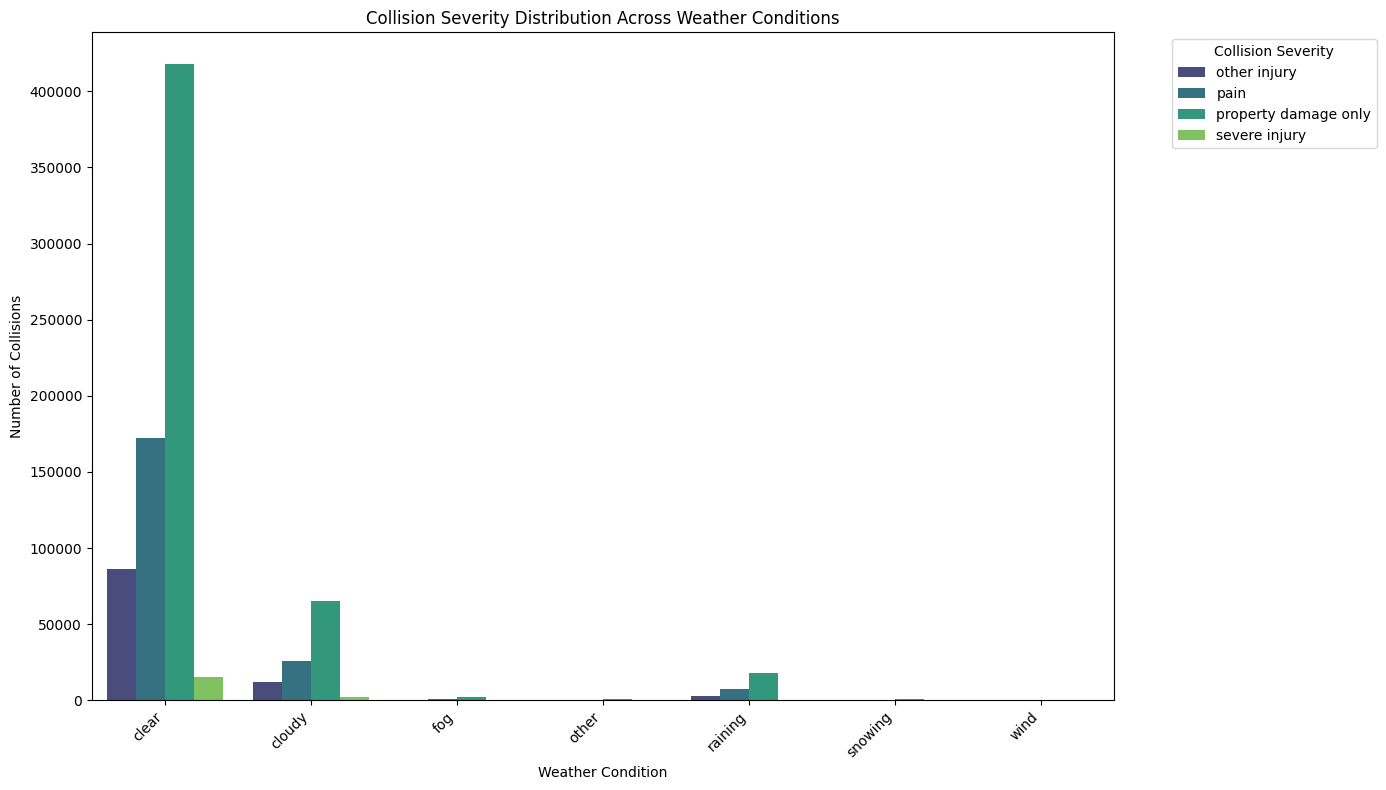

In [19]:
# Weather vs. Collision Severity

# Convert to Pandas

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Group by weather_1 and collision_severity, then count occurrences
weather_severity_counts = collisions_df.groupby(['weather_1', 'collision_severity']).size().reset_index(name='count')

# Sort by count for better visualization (optional, depends on desired focus)
# weather_severity_counts = weather_severity_counts.sort_values(by='count', ascending=False)

# Plot the relationship using a grouped bar chart or stacked bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='weather_1', y='count', hue='collision_severity', data=weather_severity_counts, palette='viridis')
plt.title('Collision Severity Distribution Across Weather Conditions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Collision Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

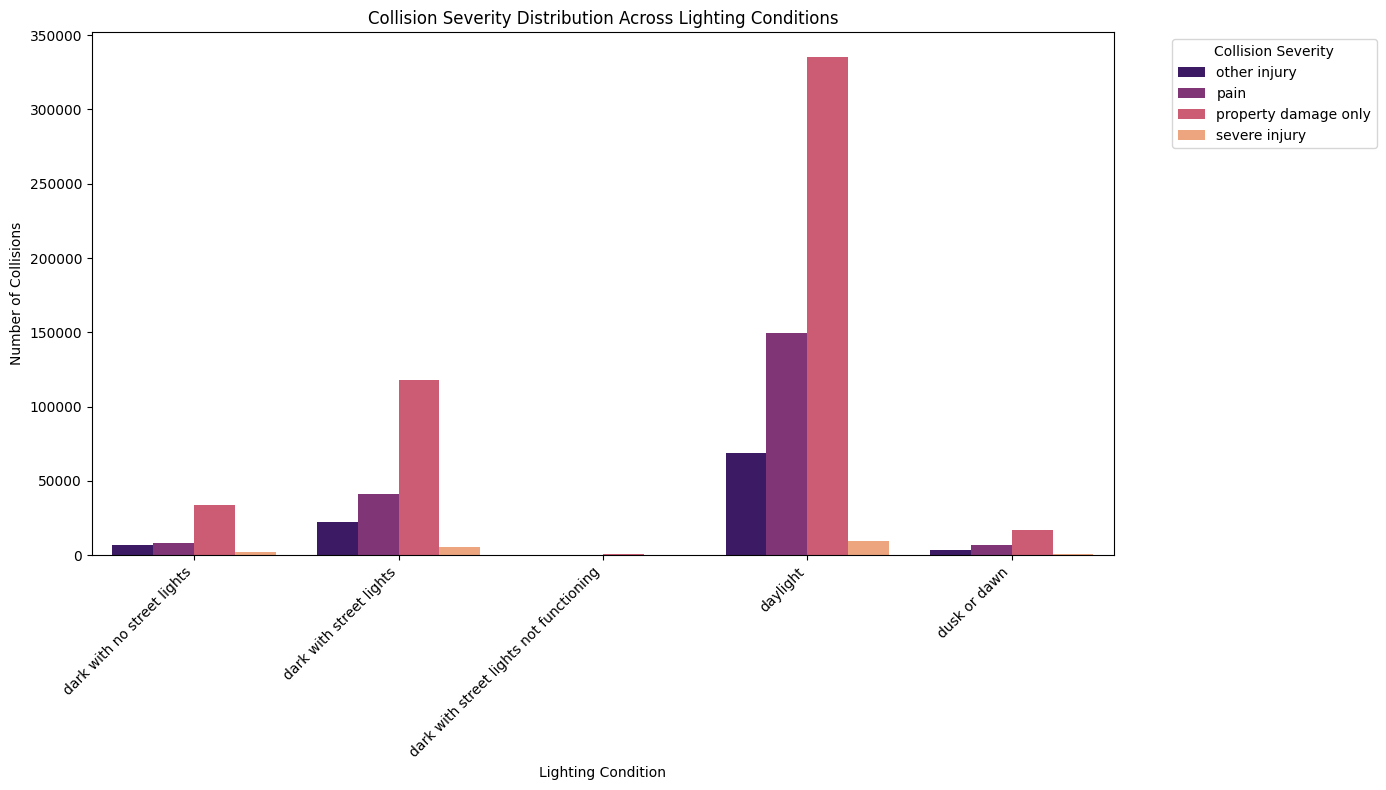

In [20]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas

# Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Group by lighting and collision_severity, then count occurrences
lighting_severity_counts = collisions_df.groupby(['lighting', 'collision_severity']).size().reset_index(name='count')

# Plot the relationship using a grouped bar chart
plt.figure(figsize=(14, 8))
sns.barplot(x='lighting', y='count', hue='collision_severity', data=lighting_severity_counts, palette='magma')
plt.title('Collision Severity Distribution Across Lighting Conditions')
plt.xlabel('Lighting Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Collision Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

/tmp/ipykernel_5615/3515016734.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collisions_df['collision_date'] = pd.to_datetime(collisions_df['collision_date'])
/tmp/ipykernel_5615/3515016734.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  collisions_df['day_of_week'] = collisions_df['collision_date'].dt.day_name()
/tmp/ipykernel_5615/3515016734.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `

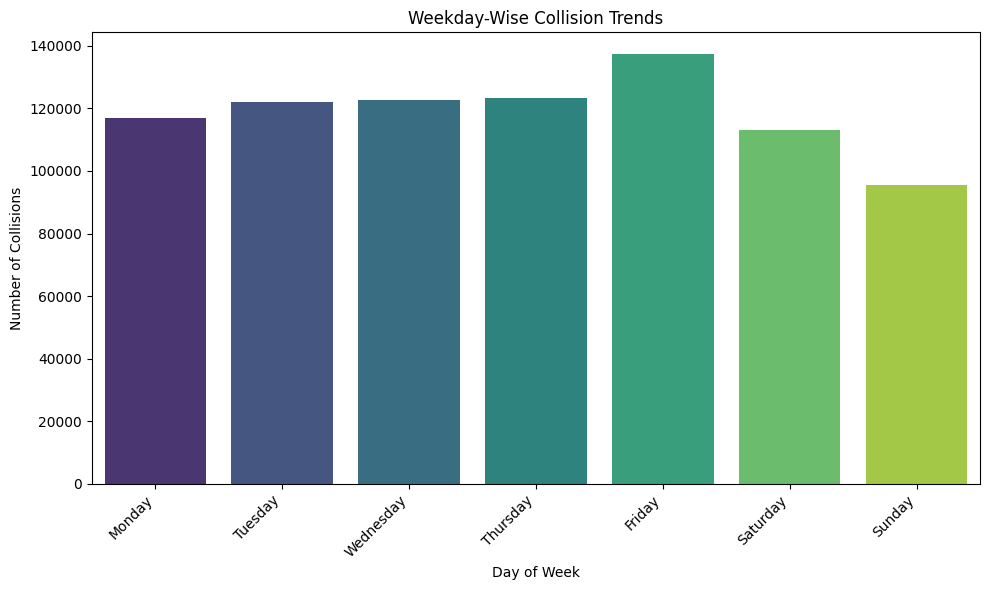

In [21]:
# Extract the weekday

# Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Ensure 'collision_date' is datetime type
collisions_df['collision_date'] = pd.to_datetime(collisions_df['collision_date'])

# Extract the weekday
collisions_df['day_of_week'] = collisions_df['collision_date'].dt.day_name()

# Count collisions per weekday
weekday_counts = collisions_df['day_of_week'].value_counts().reset_index()
weekday_counts.columns = ['day_of_week', 'count']

# Define the order of days for plotting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_counts['day_of_week'] = pd.Categorical(weekday_counts['day_of_week'], categories=day_order, ordered=True)
weekday_counts = weekday_counts.sort_values('day_of_week')

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='day_of_week', y='count', data=weekday_counts, palette='viridis')
plt.title('Weekday-Wise Collision Trends')
plt.xlabel('Day of Week')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

/tmp/ipykernel_5615/1160976916.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='county', y='collision_count', data=top_counties_df, palette='Spectral')


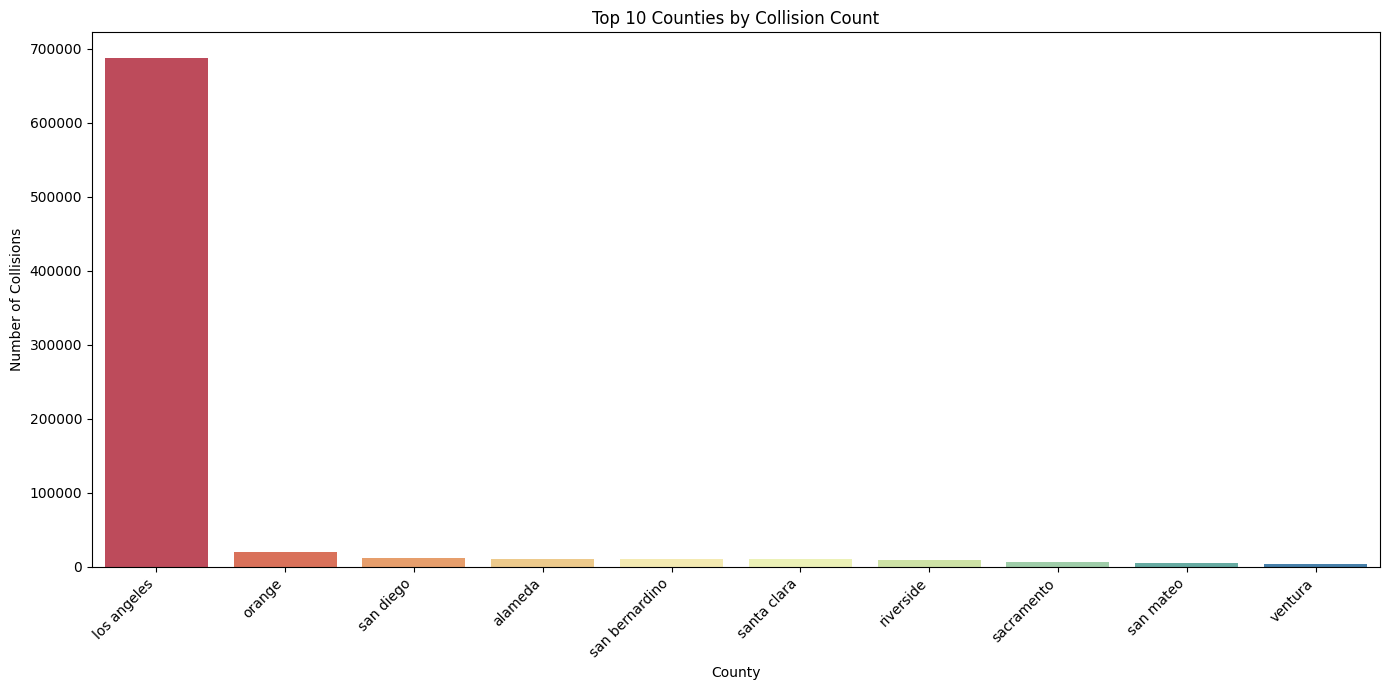

In [22]:
# Spatial Analysis

# Collision Density by County

# Plot the map
# Spatial Analysis

# Collision Density by County

# Plot the mapimport matplotlib.pyplot as plt
import seaborn as sns

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Count collisions by county
county_collision_counts = collisions_df['caltrans_county'].value_counts().reset_index()
county_collision_counts.columns = ['county', 'collision_count']

# Get the top 10 counties for better visualization
top_n_counties = 10
top_counties_df = county_collision_counts.head(top_n_counties)

# Plot the distribution of collisions by county
plt.figure(figsize=(14, 7))
sns.barplot(x='county', y='collision_count', data=top_counties_df, palette='Spectral')
plt.title(f'Top {top_n_counties} Counties by Collision Count')
plt.xlabel('County')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

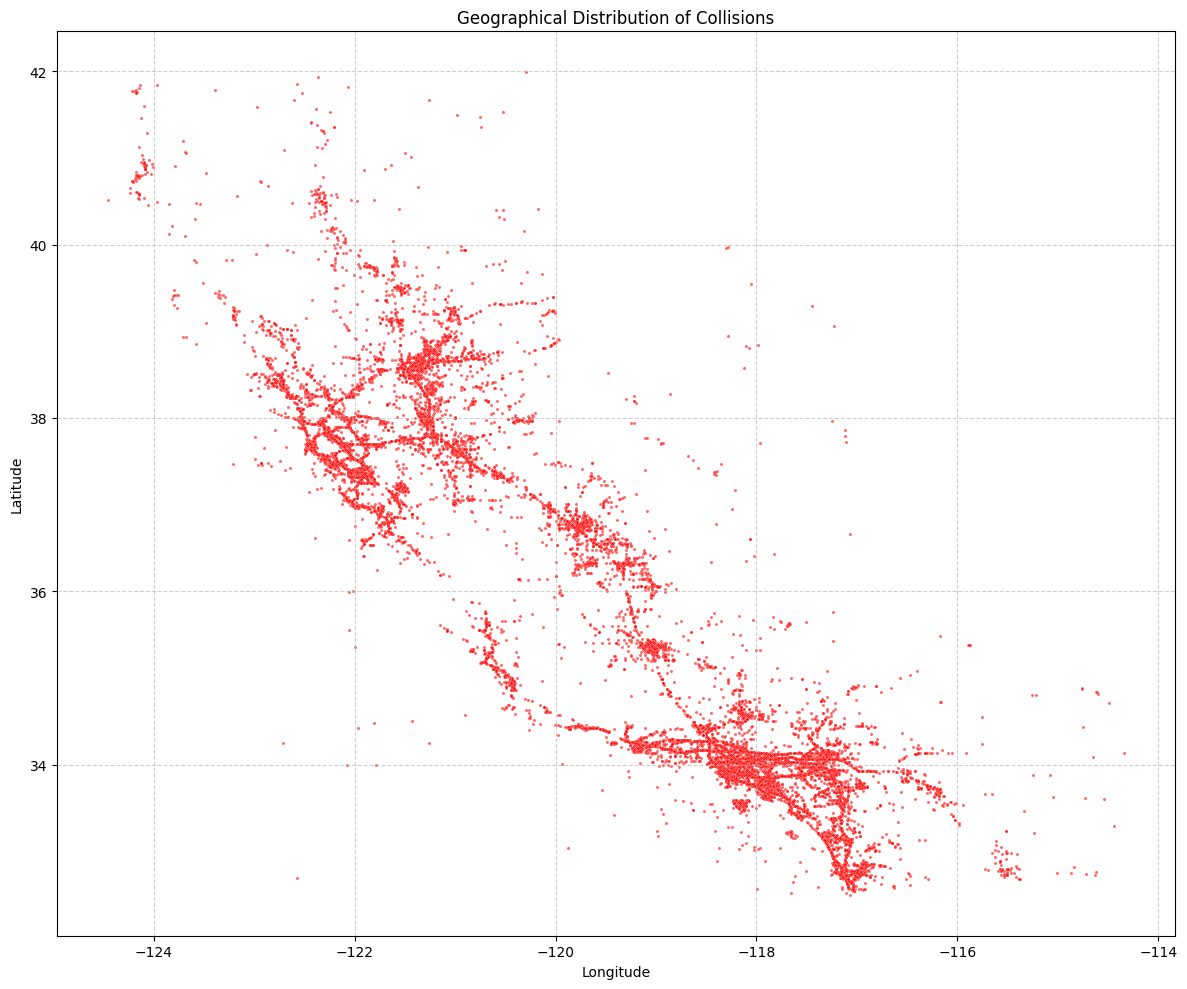

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions'].copy()

# Ensure latitude and longitude are numeric and handle any remaining non-finite values
collisions_df['latitude'] = pd.to_numeric(collisions_df['latitude'], errors='coerce')
collisions_df['longitude'] = pd.to_numeric(collisions_df['longitude'], errors='coerce')

# Drop rows where latitude or longitude are NaN (if any remained after imputation)
collisions_df.dropna(subset=['latitude', 'longitude'], inplace=True)

# Sample a subset of the data if it's too large for plotting all points
# For example, plot up to 100,000 points
if len(collisions_df) > 100000:
    collisions_df_sampled = collisions_df.sample(n=100000, random_state=42)
else:
    collisions_df_sampled = collisions_df

# Plot the scatter plot
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='longitude',
    y='latitude',
    data=collisions_df_sampled,
    alpha=0.6,
    s=5, # size of the points
    color='red'
)
plt.title('Geographical Distribution of Collisions')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [24]:
# Extract year, month, and hour from collision_date and collision_time

# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions'].copy()

# Ensure 'collision_date' is datetime type
collisions_df['collision_date'] = pd.to_datetime(collisions_df['collision_date'], errors='coerce')

# Ensure 'collision_time' is a string before converting to time, then extract hour
# Assuming collision_time is in a format like 'HH:MM:SS'
collisions_df['collision_time_dt'] = pd.to_datetime(collisions_df['collision_time'], errors='coerce').dt.time
collisions_df['hour_of_day'] = collisions_df['collision_time_dt'].apply(lambda x: x.hour if pd.notnull(x) else np.nan)

# Extract year and month
collisions_df['year'] = collisions_df['collision_date'].dt.year
collisions_df['month'] = collisions_df['collision_date'].dt.month

# Update the dataframe in the dictionary for further use
dataframes_cleaned['sample_collisions'] = collisions_df

print("Extracted 'year', 'month', and 'hour_of_day' from collision data.")

/tmp/ipykernel_5615/2891815441.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  collisions_df['collision_time_dt'] = pd.to_datetime(collisions_df['collision_time'], errors='coerce').dt.time


Extracted 'year', 'month', and 'hour_of_day' from collision data.


Q: Analyze yearly, monthly and hourly trends in collisions.

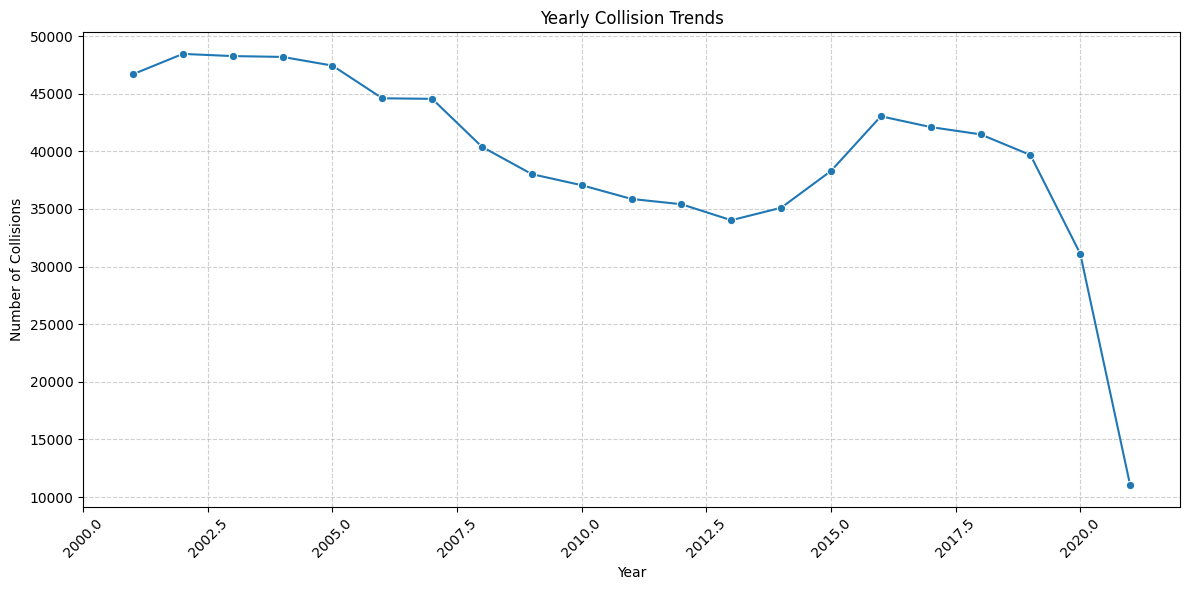

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the updated 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Yearly Trend of Collisions
yearly_counts = collisions_df['year'].value_counts().sort_index().reset_index()
yearly_counts.columns = ['year', 'count']

plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='count', data=yearly_counts, marker='o')
plt.title('Yearly Collision Trends')
plt.xlabel('Year')
plt.ylabel('Number of Collisions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

/tmp/ipykernel_5615/3933080603.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='count', data=monthly_counts, palette='viridis')


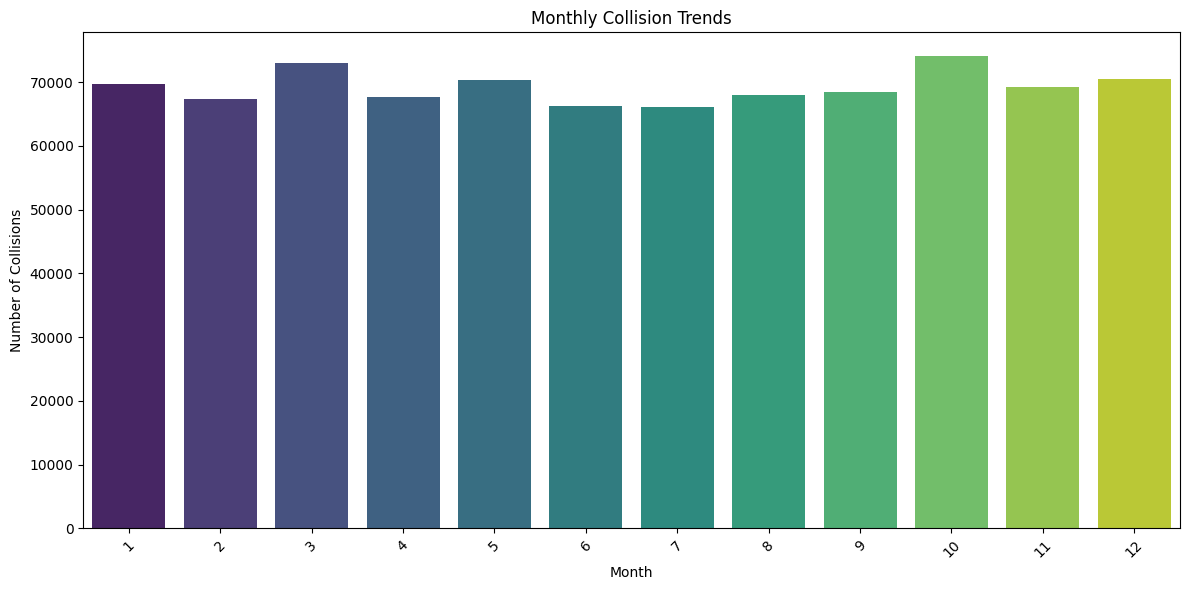

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the updated 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Monthly Trend of Collisions
monthly_counts = collisions_df['month'].value_counts().sort_index().reset_index()
monthly_counts.columns = ['month', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(x='month', y='count', data=monthly_counts, palette='viridis')
plt.title('Monthly Collision Trends')
plt.xlabel('Month')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

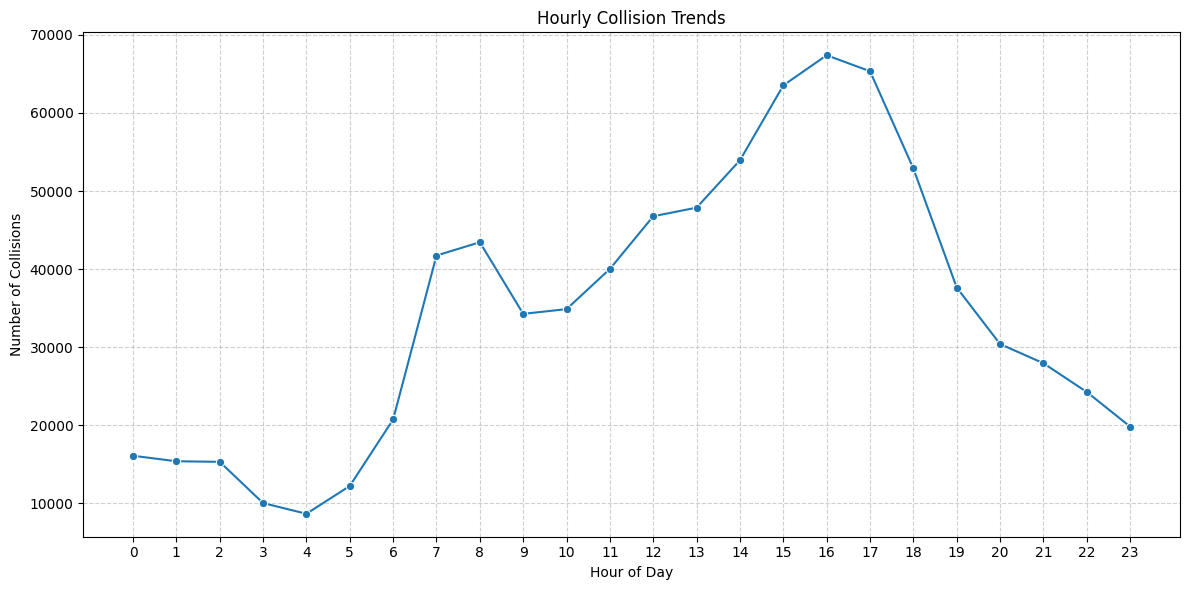

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the updated 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Hourly Trend of Collisions
hourly_counts = collisions_df['hour_of_day'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['hour_of_day', 'count']

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour_of_day', y='count', data=hourly_counts, marker='o')
plt.title('Hourly Collision Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Collisions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.tight_layout()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [34]:
# Query: Identify the top 5 counties with the most collisions
# The 'county_collision_counts' DataFrame already contains this information
# and is sorted in decreasing order of collision count. Display the top 5.
display(county_collision_counts.head(5))


,county,collision_count
0,los angeles,688113
1,orange,20242
2,san diego,12294
3,alameda,11261
4,san bernardino,11241


## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [38]:
# Display the month-wise collisions in decreasing order
monthly_collisions_sorted = monthly_counts.sort_values(by='count', ascending=False).reset_index(drop=True)

# Create a mapping for month numbers to month names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

# Apply the mapping to the 'month' column
monthly_collisions_sorted['month'] = monthly_collisions_sorted['month'].map(month_names)

print("Month-wise collisions in decreasing order:")
display(monthly_collisions_sorted.head(5))

Month-wise collisions in decreasing order:


,month,count
0,October,74128
1,March,73074
2,December,70526
3,May,70284
4,January,69654


## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

,weather_condition,count
0,clear,692039
1,cloudy,104822
2,raining,28716
3,fog,3218
4,other,930
5,snowing,776
6,wind,313


/tmp/ipykernel_5615/2627071718.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_condition', y='count', data=weather_distribution, palette='plasma')


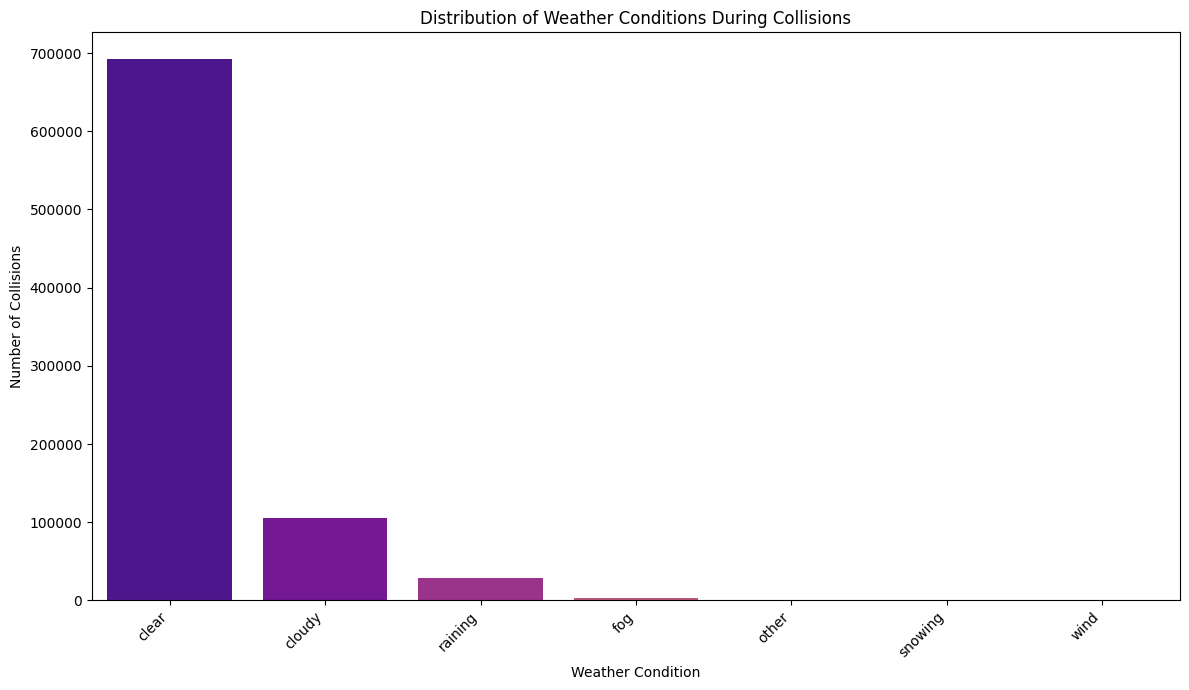

In [43]:
# Query: Find the most common weather condition during collisions
weather_distribution_sorted = weather_distribution.sort_values(by='count', ascending=False).reset_index(drop=True)
display(weather_distribution_sorted)

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming weather_distribution DataFrame is already available from previous steps
# (e.g., from cell Y-hnishxuh7F)

plt.figure(figsize=(12, 7))
sns.barplot(x='weather_condition', y='count', data=weather_distribution, palette='plasma')
plt.title('Distribution of Weather Conditions During Collisions')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [60]:
# Query: Determine the percentage of collisions that resulted in fatalities
# Get the 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Calculate the total number of collisions
total_collisions = len(collisions_df)

# Calculate the number of collisions that resulted in fatalities (killed_victims > 0)
fatal_collisions_count = collisions_df[collisions_df['killed_victims'] > 0].shape[0]

# Calculate the percentage of collisions that resulted in fatalities
percentage_fatal_collisions = (fatal_collisions_count / total_collisions) * 100 if total_collisions > 0 else 0

print(f"Total number of collisions: {total_collisions}")
print(f"Number of collisions with fatalities: {fatal_collisions_count}")
print(f"Percentage of collisions with fatalities: {percentage_fatal_collisions:.2f}%")

Total number of collisions: 830814
Number of collisions with fatalities: 0
Percentage of collisions with fatalities: 0.00%


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

,hour_of_day,count
0,0,16109
1,1,15405
2,2,15332
3,3,10053
4,4,8679
5,5,12245
6,6,20753
7,7,41744
8,8,43448
9,9,34277


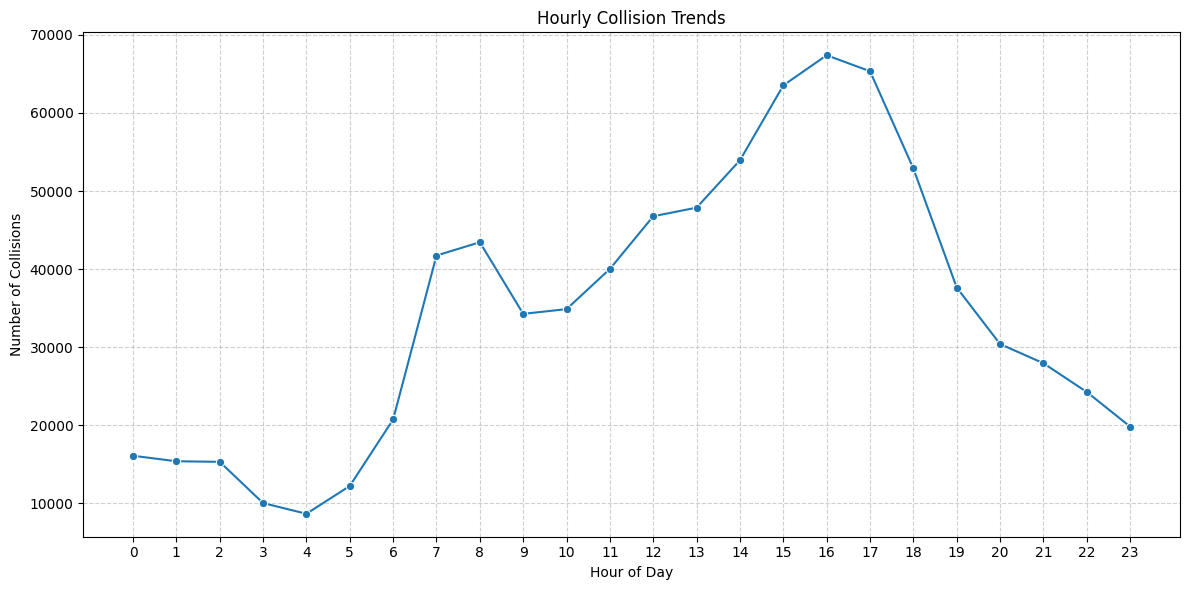

In [51]:
# Query: Find the most dangerous time of day for collisions
# Display the hourly counts directly
display(hourly_counts)

import matplotlib.pyplot as plt
import seaborn as sns

# Get the updated 'sample_collisions' DataFrame
collisions_df = dataframes_cleaned['sample_collisions']

# Hourly Trend of Collisions
hourly_counts = collisions_df['hour_of_day'].value_counts().sort_index().reset_index()
hourly_counts.columns = ['hour_of_day', 'count']

plt.figure(figsize=(12, 6))
sns.lineplot(x='hour_of_day', y='count', data=hourly_counts, marker='o')
plt.title('Hourly Collision Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Collisions')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.tight_layout()
plt.show()

## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

Top 5 Road Surface Conditions with Highest Collision Frequency:


,road_surface,collision_count
0,dry,761526
1,wet,66068
2,snowy,2401
3,slippery,809
4,H,10


/tmp/ipykernel_5615/1231904038.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='road_surface', y='collision_count', data=top_5_road_surfaces, palette='viridis')


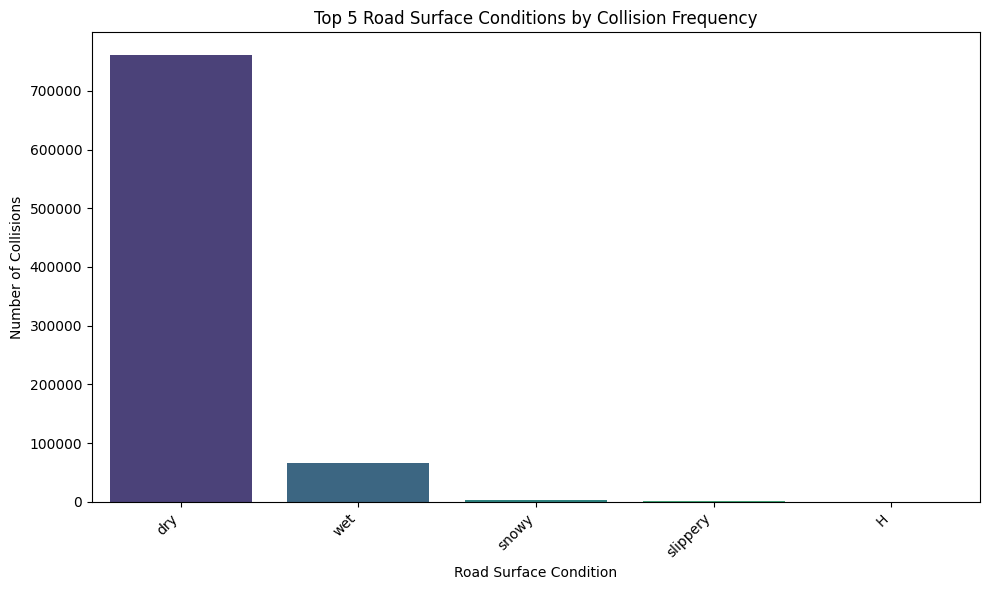

In [54]:
# Query: List the top 5 road types with the highest collision frequency

# Get the 'sample_collisions' DataFrame

import matplotlib.pyplot as plt
import seaborn as sns


collisions_df = dataframes_cleaned['sample_collisions']

# Count collisions per road surface condition
road_surface_counts = collisions_df['road_surface'].value_counts().reset_index()
road_surface_counts.columns = ['road_surface', 'collision_count']

# Display the top 5 road surface conditions
print("Top 5 Road Surface Conditions with Highest Collision Frequency:")
display(road_surface_counts.head(5))

# Assuming road_surface_counts DataFrame is already available

# Get the top 5 road surface conditions for plotting
top_5_road_surfaces = road_surface_counts.head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x='road_surface', y='collision_count', data=top_5_road_surfaces, palette='viridis')
plt.title('Top 5 Road Surface Conditions by Collision Frequency')
plt.xlabel('Road Surface Condition')
plt.ylabel('Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

Lighting Conditions with the Highest Total Collision Counts:


,lighting,count
3,daylight,562672
1,dark with street lights,187003
0,dark with no street lights,51027
4,dusk or dawn,28565
2,dark with street lights not functioning,1547


/tmp/ipykernel_5615/828207385.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='lighting', y='count', data=total_lighting_counts, palette='viridis')


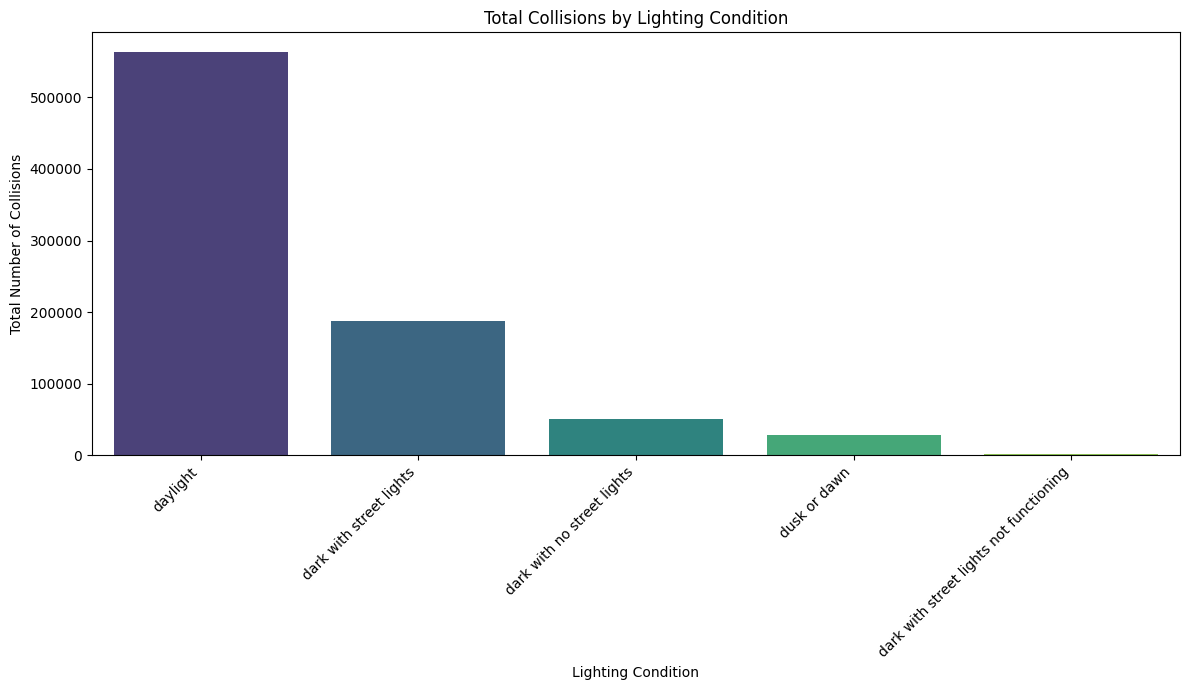

In [56]:
# Query: Find the top 3 lighting conditions that lead to the most collisions

import matplotlib.pyplot as plt
import seaborn as sns

# Query: Find the top lighting conditions that lead to the most collisions
# Group by lighting and sum the counts to get total collisions per lighting condition
total_lighting_counts = lighting_severity_counts.groupby('lighting')['count'].sum().reset_index()
total_lighting_counts = total_lighting_counts.sort_values(by='count', ascending=False)

print("Lighting Conditions with the Highest Total Collision Counts:")
display(total_lighting_counts)

# Plot the top lighting conditions by total collision count
plt.figure(figsize=(12, 7))
sns.barplot(x='lighting', y='count', data=total_lighting_counts, palette='viridis')
plt.title('Total Collisions by Lighting Condition')
plt.xlabel('Lighting Condition')
plt.ylabel('Total Number of Collisions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [59]:
# Final insights and recommendations



Insights as below based on the Collision Analysis



#1. Extensive Data Cleaning for Quality: Over a million missing values were imputed and significant outliers (e.g., ages up to 999, vehicle years outside realistic ranges, distances over 8 million units) were identified and filtered across the datasets, highlighting the critical need for robust data preprocessing.
#2. Majority of Collisions are Non-Fatal: The highest proportion of collisions resulted in 'property damage only' (504,975 incidents) or 'pain' (206,234 incidents), indicating that severe injuries or fatalities are a smaller, though critical, subset of all reported collisions.
#3. Peak Collisions in Ideal Conditions: Counter-intuitively, the vast majority of collisions (692,039) occurred under 'clear' weather conditions and during 'daylight' (562,672 incidents), suggesting driver-related factors or high traffic volume are primary contributors rather than adverse environmental conditions.
#4. Clear Temporal and Spatial Hotspots: Collisions are most frequent on Fridays (137,407), primarily between 3 PM - 6 PM (peaking at 67,386 collisions at 5 PM), and October records the highest monthly total (74,128). Spatially, Los Angeles County dominates with an exceptionally high count of 688,113 collisions.
#5. Road Surface Impact: 'Dry' road surfaces account for 761,526 collisions, making it the most frequent condition for incidents, followed by 'wet' surfaces (66,068 collisions). This underscores the prevalence of collisions during standard driving conditions and the notable increase during wet weather.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>